In [177]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm

# TODO:
# Use two matrices for VQ-VAE model lossy data compression
# Divide data into 4 x 4 batches
# Find embeddings using ADCS 4 x 4 batches
# scale patches into smaller scales

# Task:
# 1 patch'a - 1 pavyzdinis. Galima reguliuoti.
# Pasiimti viena event'a, nurodyti 8 x 8 patch'us ir kiekviena kvantuoti.


# Kiti darbai:
# Preprocessing acds reiksmiu. Clippint min ir max kokios gali buti.
# jeigu 25, tada 1, arteja 0
# Nuo geguzes 1d. dirbsiu MIF'e
# Pritiakyti pileup_ml projekto metrikas

In [178]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
BATCH_SIZE = 8
PATCH_SIZE = 8

In [179]:
# Utillities
def show_image(events: np.array) -> None:
    image_plot = events.to_images()[0][1]
    plt.imshow(image_plot, cmap='gist_yarg', origin='lower')
    plt.show()
    
def plot_patch(patch: np.array, title: str) -> None:
    plt.imshow(patch, cmap='gist_yarg', origin='lower')
    plt.title(title)
    plt.show()
    
def _get_ssim_value(image1: np.array, image2: np.array) -> float:
    image2_min_value = image2.min()
    image2_max_value = image2.max()
    
    ssmi_value = ssim(
        image1, 
        image2, 
        data_range=image2_max_value - image2_min_value,
        win_size=3
    )
    
    return ssmi_value

def _tensor_to_numpy(values: torch.Tensor) -> np.array:
    return values.cpu().detach().numpy()

def plot_metric_results(
    y_values: list[float], 
    x_values: int, 
    y_title: str, 
    title: str,
    x_label: str,
    marker: str=None
) -> None:
    print(title + " values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(x_values, y_values, marker=marker)
    plt.xlabel(x_label)
    plt.ylabel(y_title)
    plt.legend()
    plt.title(title)
    plt.show()
    
# def _get_4d_patch_tensor(patch: torch.tensor):
#     return torch.tensor(patch).\
#         unsqueeze(1)

def _get_vq_loss(recon_x: torch.tensor, x: torch.tensor, vq_loss: float) -> float:
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

def _get_bits_from_tensor(x: torch.tensor) -> float:
    return x.untyped_storage().nbytes() * 8

def _get_compression_ratio(image: torch.tensor, latent: torch.tensor, precision: int) -> float:
    image_bits = _get_bits_from_tensor(image)
    latent_bits = _get_bits_from_tensor(latent)
    
    print(f"IMAGE BITS: {image_bits}")
    print(f"LATENT BITS: {latent_bits}")
    
    return np.round(image_bits / latent_bits, precision)

def event_hits_metrics(events: PixelDigiEvent, reconstructed_events: PixelDigiEvent) -> None:
    return {
        "rmse" : compare_matching_hits(events, reconstructed_events, metric='rmse'),
        'mae': compare_matching_hits(events, reconstructed_events, metric='mae'),
        'mismatch_ratio': compare_matching_hits(events, reconstructed_events, metric='mismatch_ratio'),
        'reco_precision_recall' : compare_hit_presence(events, reconstructed_events)
    }

In [180]:
# Moduliai ir ju savybes aprasomos pixel_modules json'uose
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:09<00:00, 103.96it/s]


In [181]:
# Params
batch_size = 64
learning_rate = 1e-5
# num_epochs = 80
num_epochs = 80
channels = 1
latent_dim = 12
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.5 # Beta, the commitment loss weight for moving vectors closer to the cendroid
num_residual_hiddens = 3
num_residual_layers = 2

decay = 0.80
vq_epsilon = 1e-5

LOG_EVERY = 10


In [182]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [183]:
event_train = events_train[:SELECTED_EVENTS][0]


In [184]:
events_train_display = iter(events_train)

In [185]:
event_train_patches = event_hits_to_patches(event_train, patch_size=PATCH_SIZE)
event_train_patches_adcs = event_train_patches.as_array()
event_train_patches_adcs.shape

(15857, 64)

In [186]:
event_train_patches_adcs[0].shape

(64,)

In [187]:
len(event_train_patches_adcs)

15857

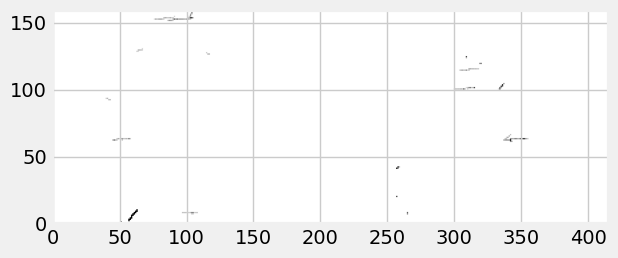

In [188]:
# plt.figure(figsize=(12, 6))
show_image(event_train)

In [189]:
class PixelPatchesDataset(torch.utils.data.Dataset):
    def __init__(self, event: PixelDigiEvent, transform=None):
        event_patches_adcs_flat = event_hits_to_patches(event, patch_size=PATCH_SIZE).as_array()
        self.event_patches_adcs = [
            event_patch_flat.reshape(PATCH_SIZE, PATCH_SIZE)
            for event_patch_flat in event_patches_adcs_flat
        ]
        self.transform = transform

    # Defining the length of the dataset
    def __len__(self) -> int:
        return len(self.event_patches_adcs)

    # Defining the method to get an item from the dataset
    def __getitem__(self, index: int) -> np.array:
        # print(self.event_patches_adcs[index])
        event_patch = self.event_patches_adcs[index]
        
        # Applying the transform
        if self.transform:
            event_patch = self.transform(event_patch)
            # print(event_patch)
        
        return event_patch

In [190]:
# X_patches_batches = torch.tensor(X_patches_batches).unsqueeze(1).float()
transform = transforms.Compose([
    transforms.ToTensor()
    # transforms.Normalize(mean=[0.5], std=[0.5])    
])
event_dataset = PixelPatchesDataset(event_train, transform)

train_loader = DataLoader(
    dataset=event_dataset, 
    batch_size=batch_size
)

# Data preprocessing
events_test_loaders = []

for event_test in events_test:
    event_dataset = PixelPatchesDataset(event_test, transform)

    event_test_loader = DataLoader(
        dataset=event_dataset, 
        batch_size=batch_size
    )
    events_test_loaders.append(event_test_loader)

In [191]:
data_sample = next(iter(train_loader))
data_sample.shape

torch.Size([64, 1, 8, 8])

In [192]:
# next(iter(train_loader))

In [193]:
# patch_tensor = _get_4d_patch_tensor(data_sample[0])
# patch_tensor.shape

In [194]:
len(train_loader)

248

In [195]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim, commitment_cost, decay, epsilon):
        super().__init__()

        self._num_embeddings = num_embeddings
        self._embedding_dim = embedding_dim

        self._embedding = nn.Embedding(self._num_embeddings, self._embedding_dim)
        self._embedding.weight.data.normal_()
        self._commitment_cost = commitment_cost

        self.register_buffer('_ema_cluster_size', torch.zeros(num_embeddings))
        self.register_buffer("_ema_w", self._embedding.weight.data.clone())
        
        self._decay = decay
        self._device = device
        self._epsilon = epsilon

    def forward(self, inputs):
        """
        Connects the module to some inputs.

        Args:
            inputs: Tensor, final dimension must be equal to embedding_dim. All other
                leading dimensions will be flattened and treated as a large batch.
        
        Returns:
            loss: Tensor containing the loss to optimize.
            quantize: Tensor containing the quantized version of the input.
            perplexity: Tensor containing the perplexity of the encodings.
            encodings: Tensor containing the discrete encodings, ie which element
                of the quantized space each input element was mapped to.
            distances
        """

        # Convert inputs from BCHW -> BHWC
        inputs = inputs.permute(1, 0, 2, 3).contiguous()
        input_shape = inputs.shape
        
        # Flatten input
        flat_input = inputs.view(-1, self._embedding_dim)
        
        # Compute distances between encoded audio frames and embedding vectors
        distances = (torch.sum(flat_input**2, dim=1, keepdim=True) 
                    + torch.sum(self._embedding.weight**2, dim=1)
                    - 2 * torch.matmul(flat_input, self._embedding.weight.t()))

        """
        encoding_indices: Tensor containing the discrete encoding indices, ie
        which element of the quantized space each input element was mapped to.
        """
        encoding_indices = torch.argmin(distances, dim=1).unsqueeze(1)
        encodings = torch.zeros(encoding_indices.shape[0], self._num_embeddings, dtype=torch.float).to(self._device)
        encodings.scatter_(1, encoding_indices, 1)


        # Sample nearest embedding
        # Use EMA to update the embedding vectors
        if self.training:
            with torch.no_grad():
                # EMA cluster size
                self._ema_cluster_size.mul_(self._decay).add_(
                    encodings.sum(0), alpha=1 - self._decay
                )

                # EMA embedding weights
                dw = torch.matmul(encodings.t(), flat_input)  # [K, C]
                self._ema_w.mul_(self._decay).add_(dw, alpha=1 - self._decay)

                # Laplace smoothing
                n = self._ema_cluster_size.sum()
                smoothed_cluster_size = (
                    (self._ema_cluster_size + self._epsilon)
                    / (n + self._num_embeddings * self._epsilon)
                    * n
                )

                self._embedding.weight.data.copy_(
                    self._ema_w / smoothed_cluster_size.unsqueeze(1)
                )

        
        avg_probs = torch.mean(encodings, dim=0)
        # Quantize and unflatten
        quantized = torch.matmul(encodings, self._embedding.weight).view(input_shape)
        # TODO: Check if the more readable self._embedding.weight.index_select(dim=1, index=encoding_indices) works better
        # Loss
        e_latent_loss = torch.mean((quantized.detach() - inputs)**2)
        commitment_loss = self._commitment_cost * e_latent_loss        
        quantized = inputs + (quantized - inputs).detach()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        """
        The perplexity a useful value to track during training.
        It indicates how many codes are 'active' on average.
        """

        quantized = quantized.view(input_shape)  # [B, H, W, C]
        
        # print(quantized.shape)
        
        quantized = quantized.permute(1, 0, 2, 3).contiguous()
        # quantized = quantized.contiguous()
        # Convert quantized from BHWC -> BCHW
        return (
            quantized, 
            commitment_loss, 
            perplexity,
            encodings
        )

In [196]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=3,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=in_channels,
                kernel_size=1,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [ ]:
# Updates
# Batch normalization reduced value shift by subtracting mean and deviding variance
# Also uses learnable parameters beta


class VQVAE(nn.Module):
    def __init__(self, hidden_channels: int, kernel_size: int, debug: bool=False):
        super(VQVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=1),
            nn.ELU(),
            # nn.Conv2d(hidden_channels, hidden_channels * 8, kernel_size=1),
            nn.ELU(),
            # Residual(hidden_channels, num_residual_layers),
            nn.Conv2d(hidden_channels, latent_dim, kernel_size=kernel_size),
            nn.ELU(),
            nn.BatchNorm2d(latent_dim)
        )
        self.debug = debug

        # Vector Quantization
        self.vq_layer = VQEmbedding(
            num_embeddings, 
            latent_dim, 
            beta, 
            decay=decay, 
            epsilon=vq_epsilon
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.BatchNorm2d(latent_dim),
            nn.ConvTranspose2d(latent_dim, hidden_channels, kernel_size=kernel_size),
            nn.ELU(),
            # Residual(hidden_channels, num_residual_layers),
            # nn.ConvTranspose2d(hidden_channels * 8, hidden_channels, kernel_size=1),
            nn.ELU(),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=1),
            nn.ELU(),
            nn.Sigmoid()
        )
        self.debug = debug

    def forward(self, x):
        z_e = self.encoder(x)        
        
        # print(f"Compressed shape: {z_e.shape}")
        
        z_q, vq_loss, perplexity, _ = self.vq_layer(z_e)
        
        # print(z_q.shape)
        
        x_recon = self.decoder(z_q)    
        
        return (
           x_recon, 
           vq_loss, 
           perplexity, 
           z_q
        )

In [198]:
model = VQVAE(
    hidden_channels = 8,
    kernel_size = 2
).to(device)


In [199]:
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

Epoch 1/80: 100%|██████████| 248/248 [00:02<00:00, 99.43it/s, Loss=0.516] 


Before compression
Before: (64, 8, 8)


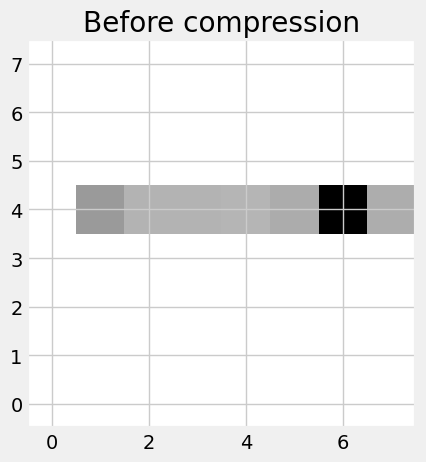

After: (1, 8, 8)
After compression


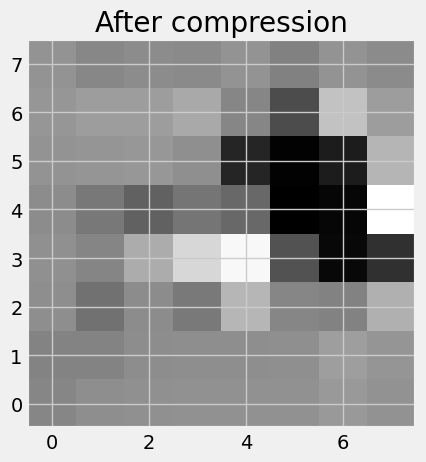

Epoch [1/80] Average Loss: 0.5355


Epoch 2/80: 100%|██████████| 248/248 [00:01<00:00, 224.24it/s, Loss=0.494]


Epoch [2/80] Average Loss: 0.5112


Epoch 3/80: 100%|██████████| 248/248 [00:01<00:00, 158.11it/s, Loss=0.473]


Epoch [3/80] Average Loss: 0.4921


...

Epoch [9/80] Average Loss: 0.3972


Epoch 10/80: 100%|██████████| 248/248 [00:01<00:00, 243.87it/s, Loss=0.374]


Epoch [10/80] Average Loss: 0.3863


Epoch 11/80: 100%|██████████| 248/248 [00:01<00:00, 245.23it/s, Loss=0.366]


Before compression
Before: (64, 8, 8)


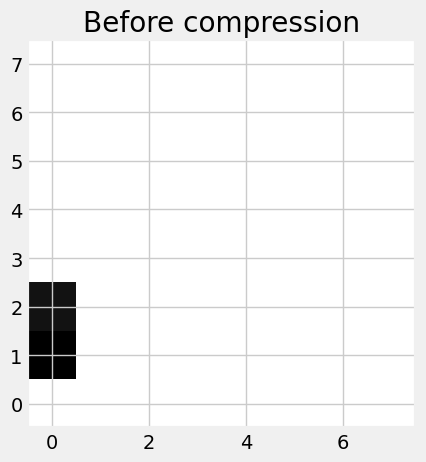

After: (1, 8, 8)
After compression


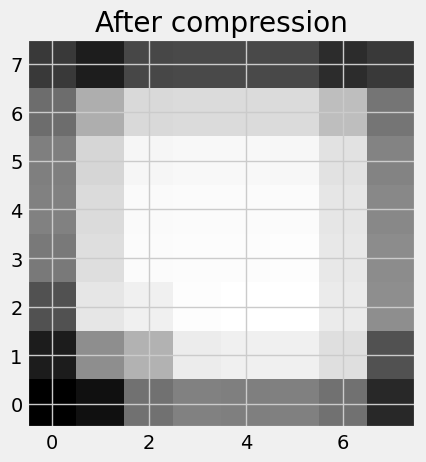

Epoch [11/80] Average Loss: 0.3767


Epoch 12/80: 100%|██████████| 248/248 [00:01<00:00, 152.10it/s, Loss=0.357]


Epoch [12/80] Average Loss: 0.3680


Epoch 13/80: 100%|██████████| 248/248 [00:01<00:00, 128.32it/s, Loss=0.349]


Epoch [13/80] Average Loss: 0.3600


...

Epoch [19/80] Average Loss: 0.3229


Epoch 20/80: 100%|██████████| 248/248 [00:01<00:00, 230.48it/s, Loss=0.311]


Epoch [20/80] Average Loss: 0.3173


Epoch 21/80: 100%|██████████| 248/248 [00:02<00:00, 109.48it/s, Loss=0.306]


Before compression
Before: (64, 8, 8)


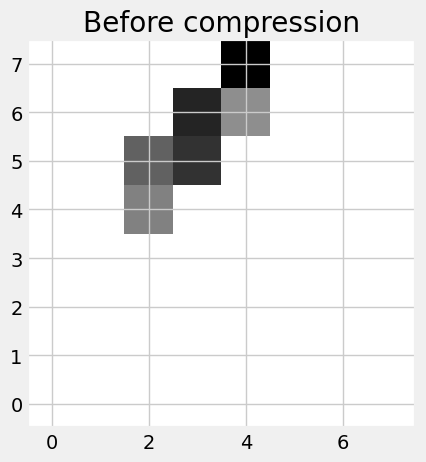

After: (1, 8, 8)
After compression


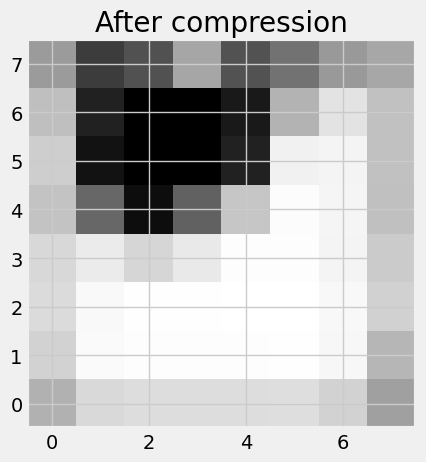

Epoch [21/80] Average Loss: 0.3125


Epoch 22/80: 100%|██████████| 248/248 [00:01<00:00, 188.22it/s, Loss=0.3]  


Epoch [22/80] Average Loss: 0.3084


Epoch 23/80: 100%|██████████| 248/248 [00:01<00:00, 209.81it/s, Loss=0.298]


Epoch [23/80] Average Loss: 0.3041


...

Epoch [29/80] Average Loss: 0.2811


Epoch 30/80: 100%|██████████| 248/248 [00:00<00:00, 291.29it/s, Loss=0.272]


Epoch [30/80] Average Loss: 0.2781


Epoch 31/80: 100%|██████████| 248/248 [00:01<00:00, 131.14it/s, Loss=0.266]


Before compression
Before: (64, 8, 8)


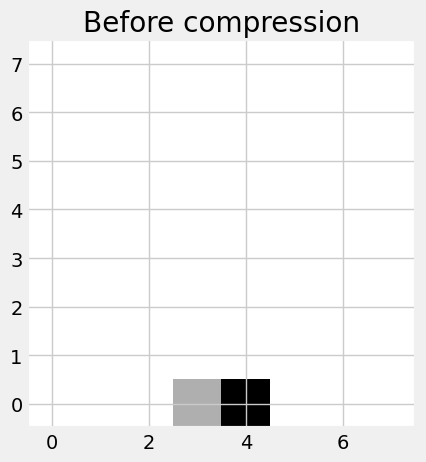

After: (1, 8, 8)
After compression


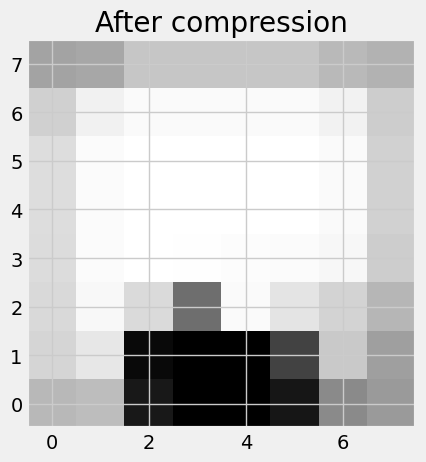

Epoch [31/80] Average Loss: 0.2742


Epoch 32/80: 100%|██████████| 248/248 [00:01<00:00, 143.71it/s, Loss=0.263]


Epoch [32/80] Average Loss: 0.2708


Epoch 33/80: 100%|██████████| 248/248 [00:02<00:00, 109.95it/s, Loss=0.262]


Epoch [33/80] Average Loss: 0.2677


...

Epoch [39/80] Average Loss: 0.2477


Epoch 40/80: 100%|██████████| 248/248 [00:01<00:00, 129.22it/s, Loss=0.24] 


Epoch [40/80] Average Loss: 0.2445


Epoch 41/80: 100%|██████████| 248/248 [00:02<00:00, 113.70it/s, Loss=0.236]


Before compression
Before: (64, 8, 8)


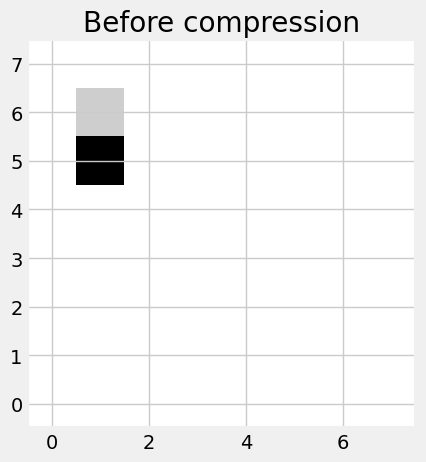

After: (1, 8, 8)
After compression


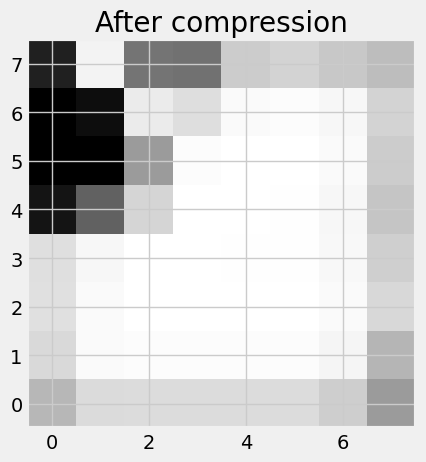

Epoch [41/80] Average Loss: 0.2414


Epoch 42/80: 100%|██████████| 248/248 [00:01<00:00, 167.74it/s, Loss=0.23] 


Epoch [42/80] Average Loss: 0.2379


Epoch 43/80: 100%|██████████| 248/248 [00:02<00:00, 123.27it/s, Loss=0.23] 


Epoch [43/80] Average Loss: 0.2345


...

Epoch [49/80] Average Loss: 0.2134


Epoch 50/80: 100%|██████████| 248/248 [00:01<00:00, 164.02it/s, Loss=0.205]


Epoch [50/80] Average Loss: 0.2097


Epoch 51/80: 100%|██████████| 248/248 [00:01<00:00, 139.44it/s, Loss=0.2]  


Before compression
Before: (64, 8, 8)


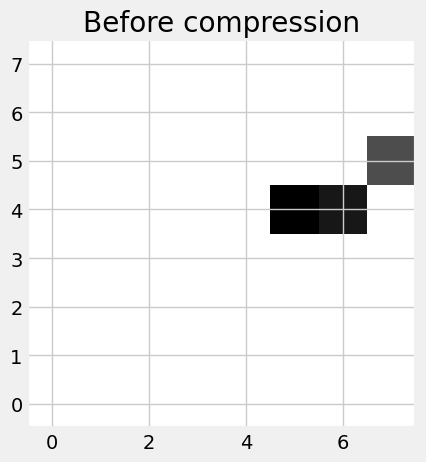

After: (1, 8, 8)
After compression


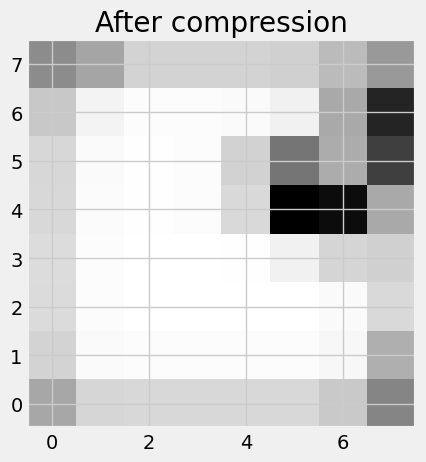

Epoch [51/80] Average Loss: 0.2061


Epoch 52/80: 100%|██████████| 248/248 [00:00<00:00, 280.25it/s, Loss=0.199]


Epoch [52/80] Average Loss: 0.2024


Epoch 53/80: 100%|██████████| 248/248 [00:01<00:00, 130.78it/s, Loss=0.195]


Epoch [53/80] Average Loss: 0.1988


...

Epoch [59/80] Average Loss: 0.1806


Epoch 60/80: 100%|██████████| 248/248 [00:01<00:00, 155.94it/s, Loss=0.172]


Epoch [60/80] Average Loss: 0.1784


Epoch 61/80: 100%|██████████| 248/248 [00:00<00:00, 272.80it/s, Loss=0.173]


Before compression
Before: (64, 8, 8)


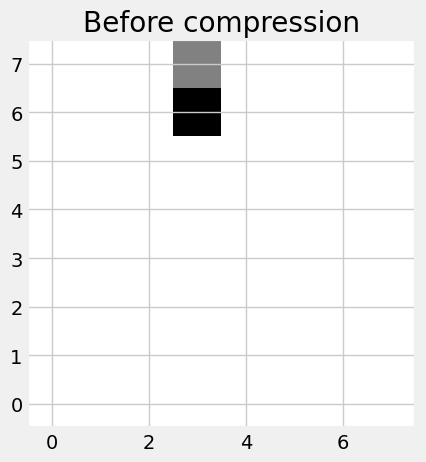

After: (1, 8, 8)
After compression


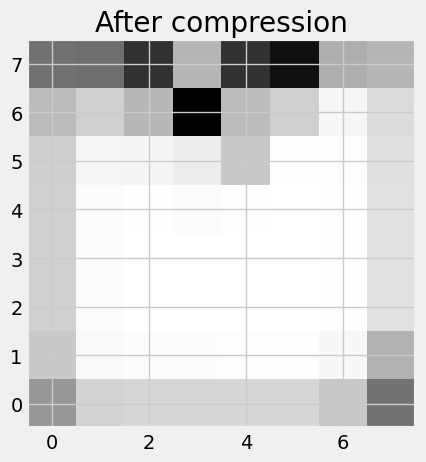

Epoch [61/80] Average Loss: 0.1762


Epoch 62/80: 100%|██████████| 248/248 [00:01<00:00, 159.10it/s, Loss=0.169]


Epoch [62/80] Average Loss: 0.1734


Epoch 63/80: 100%|██████████| 248/248 [00:00<00:00, 314.95it/s, Loss=0.167]


Epoch [63/80] Average Loss: 0.1719


...

Epoch [69/80] Average Loss: 0.1625


Epoch 70/80: 100%|██████████| 248/248 [00:01<00:00, 141.41it/s, Loss=0.156]


Epoch [70/80] Average Loss: 0.1612


Epoch 71/80: 100%|██████████| 248/248 [00:01<00:00, 132.83it/s, Loss=0.158]


Before compression
Before: (64, 8, 8)


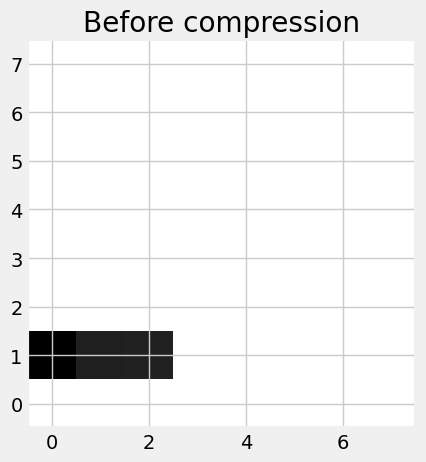

After: (1, 8, 8)
After compression


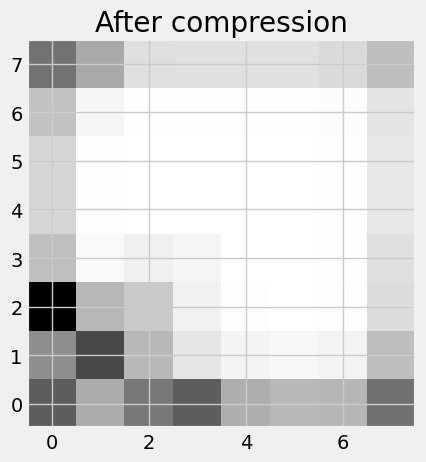

Epoch [71/80] Average Loss: 0.1600


Epoch 72/80: 100%|██████████| 248/248 [00:00<00:00, 299.64it/s, Loss=0.155]


Epoch [72/80] Average Loss: 0.1588


Epoch 73/80: 100%|██████████| 248/248 [00:01<00:00, 237.50it/s, Loss=0.155]


Epoch [73/80] Average Loss: 0.1577


...

Epoch [78/80] Average Loss: 0.1528


Epoch 79/80: 100%|██████████| 248/248 [00:00<00:00, 346.12it/s, Loss=0.146]


Epoch [79/80] Average Loss: 0.1517


Epoch 80/80: 100%|██████████| 248/248 [00:01<00:00, 145.10it/s, Loss=0.146]

Epoch [80/80] Average Loss: 0.1508


In [200]:
# loss
average_loss_values = []
# ssim
ssim_values = []

# perplexity
perplexity_values = []

# Cutting after certain epochs
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=30,   # every 30 epochs
#     gamma=0.01       # multiply LR by 0.1
# )

# num_epochs = 20
idx_validation = 0
patch_test_cursor = iter(events_test_loaders[0])

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    progress_bar = tqdm(
        enumerate(train_loader), 
        total=len(train_loader), 
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        # X_adcs = X_adcs.to(device)
        # X_noisy = X_adcs.float() + 0.01 + torch.randn_like(X_adcs)
        # X_noisy = X_noisy.to(device).permute(0, 1, 2, 3)
        X_adcs_tr = X_adcs.to(device).permute(0, 1, 2, 3)
        
        # print(f"Inputing to model: {str(X_adcs.shape)}")
        
        (
            recon_patch, 
            vq_loss, 
            perplexity, 
            _
        ) = model(
           X_adcs_tr
        )
        recon_patch = recon_patch.float().to(device)      
        
        loss = _get_vq_loss(recon_patch, X_adcs_tr, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss': loss.item()})
        # scheduler.step()
    
    if epoch % LOG_EVERY == 0:
        with torch.no_grad():            
            # selecting events before reconstruction using one test loader as validation
            patch_test = next(patch_test_cursor) 
            patch_test = patch_test.to(device)           
            print("Before compression")
            
            patch_test_ts = _tensor_to_numpy(
                patch_test.squeeze(1)
            )
            
            print(f"Before: {patch_test_ts.shape}")
            
            plot_patch(patch_test_ts[0], "Before compression")
            
            (
                recon_patch, 
                _, 
                perplexity, 
                _                
            ) = model(patch_test)
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch[0]
            )
            print(f"After: {recon_patch_np.shape}")
            print("After compression")
            
            plot_patch(recon_patch_np[0], "After compression")
        
    avg_loss = train_loss / len(train_loader)
    average_loss_values.append(avg_loss)
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

In [201]:
# TODO: Try fitting all patch'es to VQ-VAE, get calculated bits of patches and total hits per event.
# TODO: Calculate ratio before how many bits were used per patch and after compression how many bits were 
# used per patch 

In [202]:
# Test model with unseen data
events_test_patches_adcs = [
    event_hits_to_patches(event, PATCH_SIZE).as_array()
    for event in events_test[:SELECTED_EVENTS]
]

events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test[:SELECTED_EVENTS]
]
print(f"Events test: {len(events_test_patches_adcs)}")
print(f"Event patches: {len(events_test_patches[0])}")


Events test: 1
Event patches: 8452


In [203]:
X_test_patch = events_test_patches_adcs[0][0]
X_test = torch.tensor(X_test_patch).to(device).float()
X_test = X_test.reshape(
    PATCH_SIZE, 
    PATCH_SIZE
).unsqueeze(1).permute(1, 0, 2).unsqueeze(1)


In [204]:
X_test.shape

torch.Size([1, 1, 8, 8])

In [205]:
model.eval()

with torch.no_grad():
    model = VQVAE(
        hidden_channels = 3,
        kernel_size = 2    
    ).to(device)
    z = model.encoder(X_test)
    z, vq_loss, perplexity, encodings = model.vq_layer(z)
    print(f"Latent shape: {z.shape}")
    
    used_codes = torch.unique(encodings)
    num_used = used_codes.numel()
    
    print(f"Codebook unique encodings:{len(used_codes)}")
    print(encodings.shape)
    print(encodings.unique())
    
    codebook = model.vq_layer._embedding.weight
    codebook_size = codebook.element_size() * codebook.numel()
    
    print(f"Codebook size: {len(used_codes)}")
    

Latent shape: torch.Size([1, 12, 6, 6])
Codebook unique encodings:2
torch.Size([36, 128])
tensor([0., 1.], device='cuda:0')
Codebook size: 2


In [206]:
events_test[0].det_ids

array([303042564, 303042564, 303042564, ..., 353339396, 353339396,
       353339396], shape=(24791,), dtype=int32)

/tmp/ipykernel_276305/1883693864.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Average reconstruction loss over epochs values over epochs


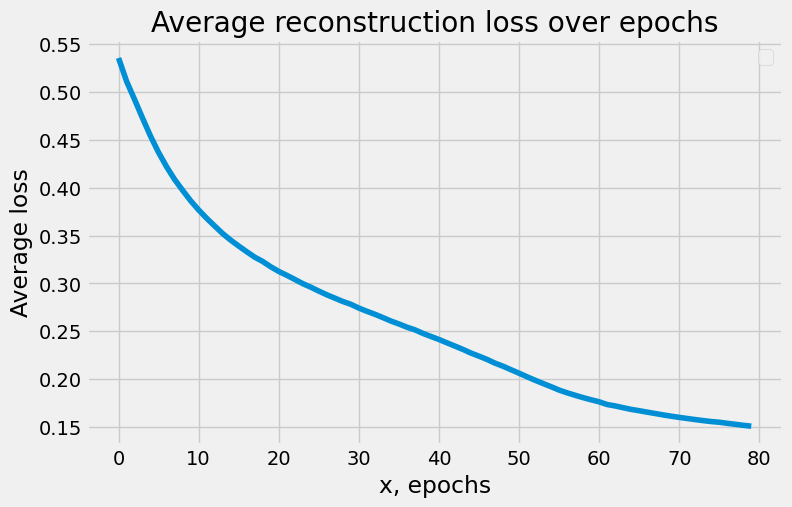

In [207]:
plot_metric_results(
    average_loss_values, 
    list(range(num_epochs)), 
    "Average loss", 
    "Average reconstruction loss over epochs",
    "x, epochs"
)

In [208]:
torch.save(model.state_dict(), "vq_vae_pileup.pth")

In [209]:
# TODO: change debug for option change event_hit_test count
# def _get_reshape_tensor(patch_flatten: np.array) -> torch.tensor:
#     patch = patch_flatten.reshape(PATCH_SIZE, PATCH_SIZE)
#     patch_tensor_ini = torch.tensor(patch)
#     # patch_tensor = patch_tensor_ini.unsqueeze(1).unsqueeze(1).transpose(0, 2)
#     patch_tensor = patch_tensor_ini.unsqueeze(1)
#     patch_tensor = patch_tensor.float()
#     patch_tensor = patch_tensor.to(device)
#     return patch_tensor

# events_test_patches_tensors = []
# for event_test_patches_adcs in events_test_patches_adcs:
#     event_test_patches_tensors = list(map(_get_reshape_tensor, event_test_patches_adcs))
#     event_test_patch_first = event_test_patches_tensors[0]
#     print(f"DEBUG: first event shape: {event_test_patch_first.shape}")
    
#     events_test_patches_tensors.append(event_test_patches_tensors)

In [210]:
# len(event_test_patches_tensors)

IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 1 compression ratio (original/q_latent): 0.1481481481


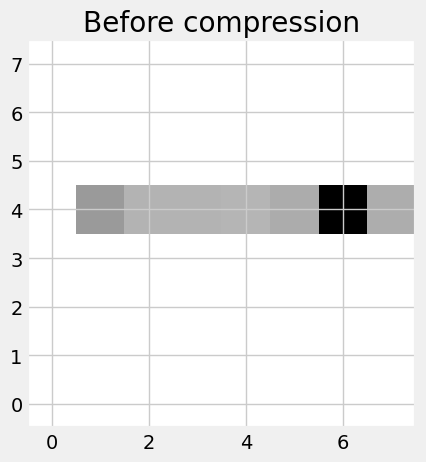

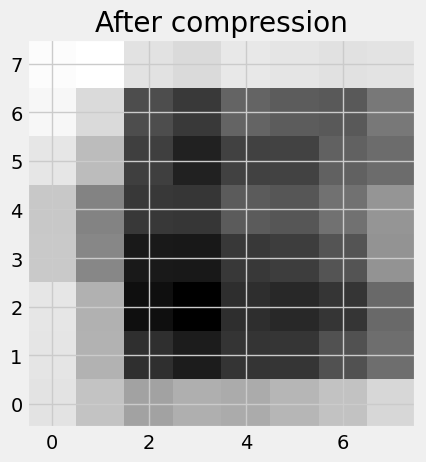

IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 2 compression ratio (original/q_latent): 0.1481481481


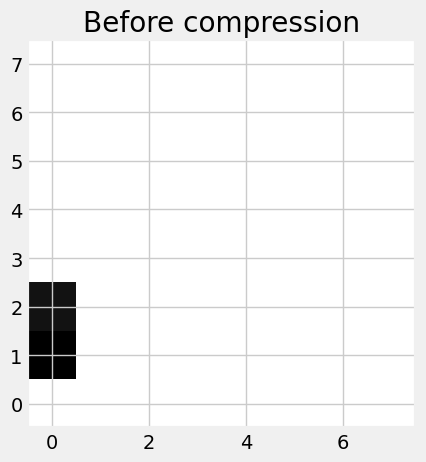

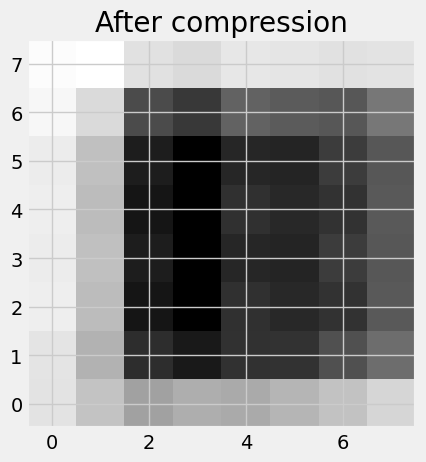

IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 3 compression ratio (original/q_latent): 0.1481481481
IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 4 compression ratio (original/q_latent): 0.1481481481
IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 5 compression ratio (original/q_latent): 0.1481481481
IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 6 compression ratio (original/q_latent): 0.1481481481
IMAGE BITS: 131072
LATENT BITS: 884736
Patch compression statistics
Before: torch.Size([64, 1, 8, 8])
After compression
After: (8, 8)
Event Patch 7 compression ratio (original/q_latent): 0.1481481481


In [211]:
# Performing test on unseen data
plot_patches_debug = 2
plotted_patches = 0
fill_value = 0
decompressed_events = []
T_SIMILAR = 0.7
T_DISSIMILAR = 0
T_IDENTICAL = 0.9
T_CODEBOOK = 2

model.load_state_dict(torch.load("vq_vae_pileup.pth"))
model = model.to(device)
model.eval() 

# compressing patches
events_test_patches = [
    event_hits_to_patches(event, PATCH_SIZE)
    for event in events_test
]

# compressing / decompressing each event patch adcs
for (i, event_test_loader) in enumerate(events_test_loaders):
    event_adcs_merged = []
    
    for (j, event_patch) in enumerate(event_test_loader):
        with torch.no_grad():
            event_patch = event_patch.to(device)
            (
                recon_patch, 
                _, 
                perplexity, 
                z_q
            ) = model(event_patch)
            
            # Reconstructed adcs
            patch_original = _tensor_to_numpy(
                event_patch.squeeze(1)[0]
            )
            
            recon_patch_np = _tensor_to_numpy(
                recon_patch.squeeze(1)[0]
            )
            
            compression_ratio = _get_compression_ratio(
                image=event_patch,
                latent=z_q,
                precision=10
            )
            
            print("Patch compression statistics")
            print(f"Before: {event_patch.shape}")
            print("After compression")
            print(f"After: {recon_patch_np.shape}")            
            print(f"Event Patch {j + 1} compression ratio (original/q_latent): {compression_ratio}")
            
            if plotted_patches < plot_patches_debug:
                plot_patch(patch_original, "Before compression")        
                plot_patch(recon_patch_np, "After compression")
                plotted_patches += 1
            
            # compression_ratio_values.append(compression_ratio)
            
            # Saving statistics
            perplexity_values.append(perplexity.item())
            
            adcs_decoded = recon_patch_np.flatten()
            event_adcs_merged.append(adcs_decoded)
    
    # saving new decompressed
    # checking occupancy
    X_patches = np.concatenate(event_adcs_merged)
    X_occupancy = (X_patches != fill_value)
    
    event_test_patches = events_test_patches[i]
    
    # # Make the first decompressed event
    event_patches_decompressed = PixelEventPatches(
        detector=pix_det,
        patch_size=PATCH_SIZE,
        event_id=event_test_patches.event_id,
        det_ids=event_test_patches.det_ids,
        rows=event_test_patches.rows,
        cols=event_test_patches.cols,
        adcs=X_patches,
        occupancy=X_occupancy
    )
    event_hits = event_patches_to_hits(
        event_patches_decompressed
    )
    decompressed_events.append(event_hits)
    
    print(f"Showing event_id = {event_hits.id_} statistics")
    
    event_codebooks_high = sum([perplexity > T_CODEBOOK for perplexity in perplexity_values])
    event_codebooks_low = sum([perplexity < T_CODEBOOK for perplexity in perplexity_values])
    
    print("-----------")
    print(f"Above limit: {T_CODEBOOK}, codebook count: {event_codebooks_high}")
    print(f"Lower limit: {T_CODEBOOK}, codebook count: {event_codebooks_low}")
    
    print(f"Showing decompressed vs original patches ssim:")
    
    identical_count = sum(list(map(lambda x: x > T_IDENTICAL, ssim_values)))
    similar_count = sum(list(map(lambda x: x > T_SIMILAR and x < T_IDENTICAL, ssim_values)))
    dissimilar_count = sum(list(map(lambda x: x < T_DISSIMILAR, ssim_values)))
    
    print("-----------")
    print(f"Identical patches: {identical_count}")
    print(f"Similar patches: {similar_count}")
    print(f"Dissimilar patches: {dissimilar_count}")
    print("-----------")  

In [212]:
# # testing with new data
# # DEBUG:
# plot_patches_debug = 2 # selecting two patches for plotting. 
# plotted_patches = 0
# plot_elements = 20
# fill_value = 0

# T_SIMILAR = 0.7
# T_DISSIMILAR = 0
# T_IDENTICAL = 0.9
# T_CODEBOOK = 2


# model.load_state_dict(torch.load("vq_vae_pileup.pth"))
# model = model.to(device)
# model.eval()   

# decompressed_events = [] 
# perplexity_values = []
# codebook_sizes = []

# # TODO: SSIM values for extra material. Extra validation that everything works
# ssim_values = []

# # TODO: add frechet inception score
# # https://en.wikipedia.org/wiki/Fr%C3%A9chet_inception_distance

# print("Check patch compressed latent dimensions")
# for (i, event_test_patch_tensors) in enumerate(events_test_patches_tensors):
#     event_adcs_merged = []
#     event_test_patches = events_test_patches[i]
#     event_used_bits = []
#     compression_ratio_values = []
    
#     for (j, event_test_patch_tensor) in enumerate(event_test_patch_tensors):
#         print(f"Patch IDX = {j + 1} compression results")

#         event_patches_decompressed = None
#         event_hits = None

#         print("Testing with unseen data")

#         with torch.no_grad():
#             event_test_patch = _tensor_to_numpy(
#                 event_test_patch_tensor.squeeze(1).view(
#                     (PATCH_SIZE, PATCH_SIZE)
#                 )
#             )
            
#             (
#                 recon_patch, 
#                 _, 
#                 perplexity, 
#                 z_q
#             ) = model(event_test_patch_tensor)
            
#             # Reconstructed adcs
#             recon_patch_np = _tensor_to_numpy(
#                 event_test_patch_tensor.squeeze(1).view(
#                     (PATCH_SIZE, PATCH_SIZE)
#                 )
#             )
            
#             patch_original = _tensor_to_numpy(
#                 event_test_patch_tensor.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
#             )
#             recon_patch_np = _tensor_to_numpy(
#                 recon_patch.squeeze(1).view((PATCH_SIZE, PATCH_SIZE))
#             )
#             # ssim_value = _get_ssim_value(
#             #     patch_original,
#             #     recon_patch_np
#             # )
#             compression_ratio = _get_compression_ratio(
#                 image=event_test_patch_tensor,
#                 latent=z_q,
#                 precision=10
#             )
            
#             print("Patch compression statistics")
#             print(f"Before: {event_test_patch.shape}")
#             print("After compression")
#             print(f"After: {recon_patch_np.shape}")            
#             print(f"Event Patch {j + 1} compression ratio (original/q_latent): {compression_ratio}")
            
#             compression_ratio_values.append(compression_ratio)
            
#             # Saving statistics
#             perplexity_values.append(perplexity.item())
#             # ssim_values.append(
#             #    ssim_value.item()
#             # )
            
#             if plotted_patches < plot_patches_debug:
#                 plot_patch(event_test_patch, "Before compression")        
#                 plot_patch(recon_patch_np, "After compression")
#                 plotted_patches += 1
            
#             adcs_decoded = recon_patch_np.flatten()
#             event_adcs_merged.append(adcs_decoded)
            
#             event_used_bits.append(adcs_decoded.nbytes * 8)
    
#     # Drawing compression scores
#     # TODO: make the plot more informative
#     plot_metric_results(
#         compression_ratio_values,
#         list(range(len(event_test_patch_tensors))),
#         "Compression ratio",
#         "Compression ratio per event patch",
#         "X, patch",
#         marker="s"
#     )
    
#     # checking occupancy
#     X_patches = np.concatenate(event_adcs_merged)
#     X_occupancy = (X_patches != fill_value)
    
         
#     # # Make the first decompressed event
#     event_patches_decompressed = PixelEventPatches(
#         detector=pix_det,
#         patch_size=PATCH_SIZE,
#         event_id=event_test_patches.event_id,
#         det_ids=event_test_patches.det_ids,
#         rows=event_test_patches.rows,
#         cols=event_test_patches.cols,
#         adcs=X_patches,
#         occupancy=X_occupancy
#     )
#     event_hits = event_patches_to_hits(
#         event_patches_decompressed
#     )
#     decompressed_events.append(event_hits)
    
#     # TODO: For compression ratio get bits of filled cells and than compare with original image
#     print(f"Showing compression ratio data, event_id = {event_hits.id_}")
#     # print(f"Patch compression ratio: {compression_ratio}")    
    
#     print(f"Showing event_id = {event_hits.id_} statistics")
    
#     event_codebooks_high = sum([perplexity > T_CODEBOOK for perplexity in perplexity_values])
#     event_codebooks_low = sum([perplexity < T_CODEBOOK for perplexity in perplexity_values])
    
#     print("-----------")
#     print(f"Above limit: {T_CODEBOOK}, codebook count: {event_codebooks_high}")
#     print(f"Lower limit: {T_CODEBOOK}, codebook count: {event_codebooks_low}")
    
#     print(f"Showing decompressed vs original patches ssim:")
    
#     identical_count = sum(list(map(lambda x: x > T_IDENTICAL, ssim_values)))
#     similar_count = sum(list(map(lambda x: x > T_SIMILAR and x < T_IDENTICAL, ssim_values)))
#     dissimilar_count = sum(list(map(lambda x: x < T_DISSIMILAR, ssim_values)))
    
#     print("-----------")
#     print(f"Identical patches: {identical_count}")
#     print(f"Similar patches: {similar_count}")
#     print(f"Dissimilar patches: {dissimilar_count}")
#     print("-----------")
    
#     # plot_metric_results(
#     #     ssim_values[:plot_elements], 
#     #     x_iterations[:plot_elements], 
#     #     "ssim values", 
#     #     "SSIM values vs patch iterations", 
#     #     "x, patches"
#     # )
    
#     # TODO: add interpretation compression ratio
#     # TODO: add missmatch ratio
    
#     # TODO:
#     # https://en.wikipedia.org/wiki/Binary_logarithm?utm_source=chatgpt.com
#     # https://ocw.mit.edu/courses/18-200-principles-of-discrete-applied-mathematics-spring-2024/mit18_200_s24_lec18.pdf?utm_source=chatgpt.com
#     # For image compression how many bits:
#     #     bits = torch.floor(torch.log2(x.float())) + 1
#     # print(bits.int())

Event test before compression


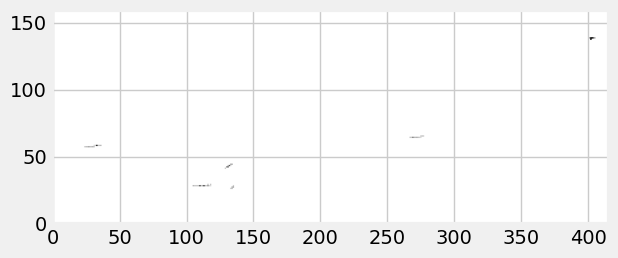

In [213]:
print("Event test before compression")
for event_test in events_test[:SELECTED_EVENTS]:
    show_image(event_test)

Event test after compression


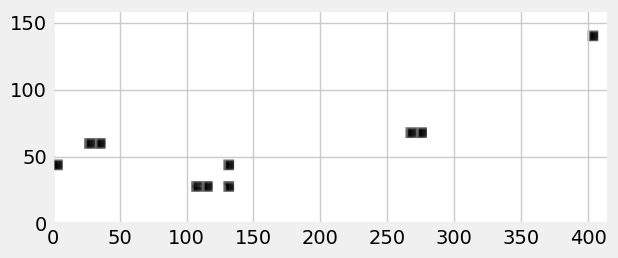

In [214]:
print("Event test after compression")
for event_test in decompressed_events[:SELECTED_EVENTS]:
    show_image(event_test)

<h2>Event compression statistics<h2>

In [215]:
# hit count in original events
n_hits_total = 0
for event_test in events_test[:SELECTED_EVENTS]:
    print(np.unique(event_test.det_ids))
    n_hits_total += len(event_test)
    
print(f"Selected events have hits: {n_hits_total}")

[303042564 303042568 303042572 ... 353335300 353338372 353339396]
Selected events have hits: 24791


In [216]:
# hit count in original events
n_hits_total_vq = 0
for decomp_event_test in decompressed_events[:SELECTED_EVENTS]:
    # print(np.unique(decomp_event_test.det_ids))
    # print([len(hit) for hit in decomp_event_test.hits])
    n_hits_total_vq += len(decomp_event_test)
    
print(f"Decompressed events have hits: {n_hits_total_vq}")

Decompressed events have hits: 8512


In [217]:
events_test[0].hits[0].adcs

array([153,  47,  65,  66,  92,  64,  67,  80,  55,  38,  55, 236,  58,
        59,  70,  75,  56,  56,  55,  62, 189,  61,  85, 192,  67,  51,
       106,  54,  42,  39,  58,  59, 111, 156,  51, 169,  49,  41,  82,
        70,  71,  86,  89,  51,  58,  58, 126,  74,  69,  80,  63,  52,
        38,  48,  60,  53, 106, 255, 255, 255, 182,  81], dtype=uint8)

In [218]:
decompressed_events[0].hits[0].adcs

array([0.45336312, 0.4978595 , 0.54677767, 0.5277387 , 0.5342546 ,
       0.5180371 , 0.5006903 , 0.47173417, 0.45174497, 0.5231296 ,
       0.71059614, 0.7374314 , 0.7024303 , 0.70197016, 0.6610544 ,
       0.62016267, 0.44929686, 0.5257433 , 0.7554859 , 0.77757525,
       0.71119034, 0.71949357, 0.70107543, 0.6276941 , 0.49065706,
       0.58481145, 0.7392252 , 0.7429092 , 0.6960203 , 0.6903883 ,
       0.6571517 , 0.5667453 , 0.4922616 , 0.5892613 , 0.6964521 ,
       0.700174  , 0.6475764 , 0.65491533, 0.61492014, 0.56514806,
       0.44964188, 0.51005095, 0.6878813 , 0.72912496, 0.68241507,
       0.6813194 , 0.63918084, 0.6229025 , 0.4259522 , 0.46623987,
       0.66715014, 0.69415677, 0.6342569 , 0.645827  , 0.6504478 ,
       0.6058316 , 0.41849372, 0.4134575 , 0.45609254, 0.46656442,
       0.44747037, 0.45109627, 0.4563879 , 0.45354658, 0.45336312,
       0.4978595 , 0.54677767, 0.5277387 , 0.5342546 , 0.5180371 ,
       0.5006903 , 0.47173417, 0.45174497, 0.5231296 , 0.71059

<h1>VQ-VAE compression metrics</h1>

In [219]:
# for i in range(SELECTED_EVENTS):
#     event = events_test[i]
#     result = 
#         event,
#         decompressed_events[i]
#     )
#     print(f"Event ID = {event.id_}")
#     print(result)

# Showing test vs reconstructed events
event_hits_metrics(
   events_test[:SELECTED_EVENTS],
   decompressed_events[:SELECTED_EVENTS] 
)

{'rmse': 100.91285980209608,
 'mae': 84.63624572753906,
 'mismatch_ratio': 1.0,
 'reco_precision_recall': (0.0606203007518797, 0.020814005082489612)}

Perplexity (code books used over patches) values over epochs


/tmp/ipykernel_276305/1883693864.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


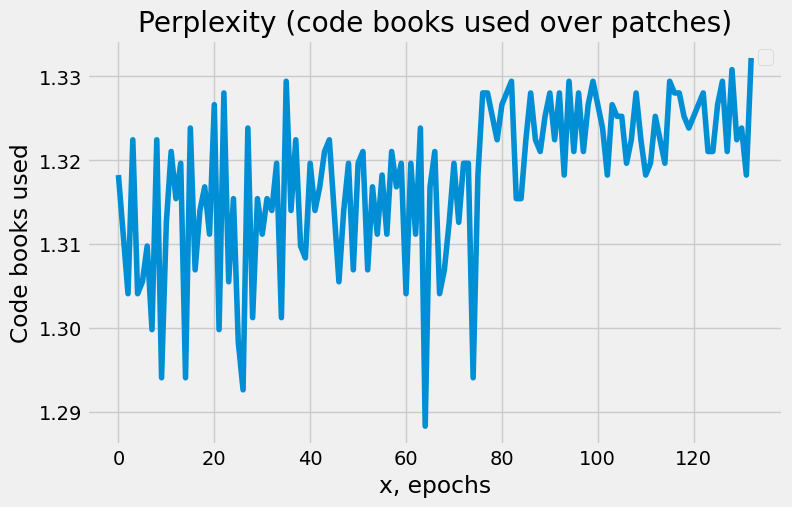

In [220]:
# perplexity
plot_metric_results(
    perplexity_values, 
    list(range(len(event_test_loader))), 
    "Code books used", 
    "Perplexity (code books used over patches)",
    "x, epochs"
)